In [8]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

from keras.layers import Layer, Input, Dense, Lambda, InputLayer, Reshape, Conv2D, Flatten, Conv2DTranspose
from keras.models import Model, Sequential
from keras import metrics
from keras.datasets import mnist, cifar10
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

# MNIST

## Вариационный автокодировщик

Напомним, что вариационный автоэнкодер — это вероятностная модель данных, основанная на непрерывной смеси распределений. В лекции мы рассмотрели случай смеси гауссиан, но здесь мы применим ВА (VAE) к бинарным изображениям MNIST (каждый пиксель либо черный, либо белый). Чтобы лучше моделировать двоичные данные, мы будем использовать непрерывную смесь биномиальных распределений: $$p(x \mid w) = \int p(x \mid t, w) p(t) dt,$$ где априорное распределение скрытой переменной $t$ — стандартное нормальное $p(t) = \mathcal{N}(t\mid 0, I)$, но вероятность того, что $(i, j)$-й пиксель черный, равна $(i, j)$-му выходу нейронной сети декодера: $$p(x_{i, j} \mid t, w) = \text{decoder}(t, w)_{i, j}.$$

Чтобы обучить эту модель, мы хотели бы максимизировать неполное логарифмическое правдоподобие нашего набора данных $$\max_w \log p(X \mid w),$$ но это очень сложно сделать в вычислительном отношении, поэтому вместо этого мы максимизируем вариационную нижнюю границу  как для исходных параметров $w$, так и для распределений $q$, которое мы определяем как кодирующую нейронную сеть (encoder) с параметрами (весами) $\phi$, которая принимает входное изображение $x$ и выводит параметры гауссовского распределения $$q(t \mid x, \phi ): \log p(X \mid w) \geq \mathcal{L}(w, \phi) \rightarrow \max_{w, \phi}.$$

Итак, в целом наша модель выглядит следующим образом: кодировщик (encoder) берет изображение $x$, выдает распределение по скрытым переменным $q(t\mid x)$, которое должно аппроксимировать апостериорное распределение $p(t\mid x)$ (по крайней мере, после обучения), моделирует точку из этого распределения $\widehat{t} \sim q(t \mid x, \phi)$ и, наконец, передает ее в декодер, который выводит распределение над изображениями.

![](https://github.com/hse-aml/bayesian-methods-for-ml/blob/master/week5/VAE.png?raw=1)

В лекции мы также обсудили, что вариационная нижняя граница имеет математическое ожидание, которое мы собираемся аппроксимировать усреднением по выборкам. Но это не тривиально, поскольку нам нужно дифференцировать это приближение. Тем не менее, мы узнали о трюке _репараметризации_, который предлагает вместо выборки из распределения $\widehat{t} \sim q(t \mid x, \phi)$ брать выборку из распределения, которое не зависит ни от каких параметров, например, стандартное нормальное, а затем детерминистически преобразовать эту выборку в нужную: $$\varepsilon \sim \mathcal{N}(0, I),\quad \widehat{t} = m(x, \phi) + \varepsilon \sigma(x, \phi).$$ Таким образом, нам не нужно беспокоиться о смещении нашего стохастического градиента, и мы можем напрямую дифференцировать нашу функцию потерь  по всем параметрам, считая текущую выборку $\varepsilon$ постоянной.



### Отрицательная вариационная нижняя граница

**Задача 1**
Получим вариационную нижнюю границу для непрерывной смеси биномиальных распределений.
$$
{\cal L(w,q)} = VLB =   \sum_{i=1}^N \text{VLB}_i =  \sum_i\mathbf{M}_{q_i}\log\frac{p(x_i\mid t_i, w) p(t_i)}{q_{i}(t_i)} = \sum_i \mathbf{M}_{q_i} \log p(x_i\mid t_i, w)  +  \underbrace{\mathbf{M}_{q_i}\log \frac{p(t_i)}{q_i(t_i)}}_{-D_{kl}(q_i(t_i)|| p(t_i))}
$$
$$
\begin{align*}
D_{kl}(q_i(t_i)|| p(t_i)) &=
\\
&=\sum_{j=1}^M\left(-\log\sigma(t_i) + \frac{\sigma^2(t_i) +\mu^2(t_i)-1}{2}\right) = M\left(-\log\sigma(t_i) + \frac{\sigma^2(t_i) +\mu^2(t_i)-1}{2}
\right)
\end{align*}
$$
Первый член в выражении для ${\cal L(w,q)}$:
\begin{align*}
\sum_i\mathbf{M}_{q_i}\log p(x_i\mid t_i, w)  &= \sum_i \int q_i(t_i)\log \prod_j p_j(t_i)^{x_{ij}}(1-p_j(t_i))^{(1-x_{ij})}\,dt =
\\
&= \sum_i \int q_i(t)\sum_jx_{ij} \log p_j(t_i) + (1-x_{ij})\log (1-p_j(t_i))\,dt = \sum_i\mathbf{M}_{q_i} BCE(x_i, p(t_i))
\end{align*}
где BCE — бинарная кросс-энтропия
$$
VLB_i =\mathbf{M}_{q_i}\left\{BCE(x_i, p(t_i)) + M\left(-\log\sigma(t_i) + \frac{\sigma^2(t_i) +\mu^2(t_i)-1}{2}\right)\right\}
$$


**Обратите внимание**, что в лекциях мы обсуждали максимизацию (Вариационная Нижняя Граница) VLB (обычно это отрицательное число), но в этом задании для удобства мы **минимизируем** **отрицательную** версию VLB (которая будет положительное число) вместо максимизации обычного VLB. В дальнейшем мы всегда будем говорить об _отрицательный_ VLB, даже если будем использовать термин VLB для краткости.


**Обратите внимание**, код будет работать с мини-батчами любого размера.

Для этого нам нужна стохастическая оценка VLB:
$$\text{VLB} = \sum_{i=1}^N \text{VLB}_i \approx \frac{N}{M}\sum_{i_s}^M \text{VLB}_{i_s}$$
где $N$ — размер набора данных, $\text{VLB}_i$ — терм VLB, соответствующий $i$-му объекту, а $M$ — размер мини-пакета (mini-batch). Но вместо этой стохастической оценки полной VLB мы будем использовать оценку отрицателбной VLB, нормализованную по размеру набора данных, т.е. в приведенной ниже функции нужно вернуть среднее значение по мини-батчу $-\frac{1}{M} \sum_{i_s}^M \text{VLB}_{i_s}$. Обычно оптимизируют эту нормализованную версию VLB, поскольку она не зависит от набора данных — вы можете написать функцию VLB один раз и использовать ее для разных наборов данных — размер набора данных не слишком сильно повлияет на скорость обучения.

In [9]:
def vlb_binomial(x, x_decoded_mean, t_mean, t_log_var):
    """Returns the value of negative Variational Lower Bound

    The inputs are tf.Tensor
        x: (batch_size x number_of_pixels) matrix with one image per row with zeros and ones
        x_decoded_mean: (batch_size x number_of_pixels) mean of the distribution p(x | t), real numbers from 0 to 1
        t_mean: (batch_size x latent_dim) mean vector of the (normal) distribution q(t | x)
        t_log_var: (batch_size x latent_dim) logarithm of the variance vector of the (normal) distribution q(t | x)

    Returns:
        A tf.Tensor with one element (averaged across the batch), VLB
    """
    cce = tf.keras.losses.CategoricalCrossentropy(axis=1)
    t_var =  tf.exp(t_log_var)
    kl = -t_log_var/2.0 + (t_var + t_mean**2 - 1)/2.0
    kl = tf.reduce_sum(kl, axis=1)
    log_p = -tf.keras.metrics.binary_crossentropy(x, x_decoded_mean)
    batch_size = x.shape[0]
    number_of_pixels = x.shape[1]
    latend_dim = t_mean.shape[1]
    result = tf.reduce_mean(number_of_pixels*log_p - kl)
    print("batch_size = {}, number_of_pixels = {} kl_size = {}".format(batch_size, number_of_pixels, kl.shape))
    return -result

In [10]:
class VLB_Loss(Layer):
    """
    Слой для добавления ошибки (нижней вариационной границы) в ошибки для нейросети
    """
    def call(self, input):
        x, x_decoded_mean, t_mean, t_log_var = input
        loss = vlb_binomial(x, x_decoded_mean, t_mean, t_log_var)
        self.add_loss(loss)
        return x_decoded_mean

    def compute_output_shape(self, input_shape):
        return input_shape[1]

### Определение Encoder / decoder

**Задание 2**  Ниже приведен код, который  определяет энкодер и декодер, и реализует выборку с приемом репараметризации в предоставленном пространстве.

In [11]:
batch_size = 100
original_dim = 784 # Number of pixels in MNIST images.
latent_dim = 10 # d, dimensionality of the latent code t.
intermediate_dim = 256 # Size of the hidden layer.
epochs = 200

x = Input(batch_shape=(batch_size, original_dim))
def create_encoder(input_dim):
    # Encoder network.
    # We instantiate these layers separately so as to reuse them later
    encoder = Sequential(name='encoder')
    encoder.add(InputLayer([input_dim]))
    encoder.add(Reshape((28, 28, 1)))
    encoder.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    encoder.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    encoder.add(Flatten())
    encoder.add(Dense(2 * latent_dim))
    return encoder
encoder = create_encoder(original_dim)

get_t_mean = Lambda(lambda h: h[:, :latent_dim])
get_t_log_var = Lambda(lambda h: h[:, latent_dim:])
h = encoder(x)
t_mean = get_t_mean(h)
t_log_var = get_t_log_var(h)

# Sampling from the distribution
#     q(t | x) = N(t_mean, exp(t_log_var))
# with reparametrization trick.
def sampling(args):
    """Returns sample from a distribution N(args[0], diag(args[1]))

    The sample should be computed with reparametrization trick.

    The inputs are tf.Tensor
        args[0]: (batch_size x latent_dim) mean of the desired distribution
        args[1]: (batch_size x latent_dim) logarithm of the variance vector of the desired distribution

    Returns:
        A tf.Tensor of size (batch_size x latent_dim), the samples.
    """
    t_mean, t_log_var = args
    t_std = tf.exp(0.5*t_log_var)
    eps = tf.random.normal(tf.shape(t_mean), mean=0, stddev=1, dtype=tf.float32)*t_std + t_mean
    return eps

t = Lambda(sampling, output_shape=(latent_dim,))([t_mean, t_log_var])

def create_decoder(input_dim):
    # Decoder network
    # We instantiate these layers separately so as to reuse them later
    decoder = Sequential(name='decoder')
    decoder.add(InputLayer([input_dim]))
    decoder.add(Dense(7 * 7 * 64, activation='relu'))
    decoder.add(Reshape((7, 7, 64)))
    decoder.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(1, kernel_size=3, padding='same', activation='sigmoid'))
    decoder.add(Flatten())
    return decoder
decoder = create_decoder(latent_dim)
x_decoded_mean = decoder(t)
x_decoded_mean = VLB_Loss()([x, x_decoded_mean, t_mean, t_log_var])

### Обучение модели

**Задание 3** Запустите указанные ниже ячейки, чтобы обучить модель с настройками по умолчанию. Измените параметры, чтобы получить лучшие результаты. Особенно обратите внимание на архитектуру кодировщика/декодера (например, использование большего количества слоев, возможно, сделав их сверточными), скорость обучения и количество эпох.

In [12]:
vae = Model(x, x_decoded_mean)
# Keras will provide input (x) and output (x_decoded_mean) to the function that
# should construct loss, but since our function also depends on other
# things (e.g. t_means), it is easier to build the loss in advance and pass
# a function that always returns it.
#vae.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001), loss=lambda x, y: loss)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07,\
                amsgrad=False, name='Adam'))

#### Загрузка и подготовка данных

In [13]:
# train the VAE on MNIST digits
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# One hot encoding.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

#### Обучение модели

In [14]:
#with tf.device('/GPU:0'):
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

hist = vae.fit(x=x_train, y=x_train,
               shuffle=True,
               epochs=epochs,
               batch_size=batch_size,
               validation_data=(x_test, x_test),
               callbacks=[early_stopping],
               verbose=1)

Epoch 1/200
batch_size = 100, number_of_pixels = 784 kl_size = (100,)
batch_size = 100, number_of_pixels = 784 kl_size = (100,)
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 230.0369batch_size = 100, number_of_pixels = 784 kl_size = (100,)
600/600 ━━━━━━━━━━━━━━━━━━━━ 63s 87ms/step - loss: 167.0731 - val_loss: 117.5685
Epoch 2/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - loss: 114.8140 - val_loss: 111.3961
Epoch 3/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 110.8072 - val_loss: 109.1444
Epoch 4/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - loss: 108.7705 - val_loss: 107.4957
Epoch 5/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - loss: 107.3598 - val_loss: 106.4529
Epoch 6/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 46s 77ms/step - loss: 106.3519 - val_loss: 105.5660
Epoch 7/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 73s 61ms/step - loss: 105.6104 - val_loss: 105.0012
Epoch 8/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - loss: 104.9885 - val_loss: 104.3950
Epoch 9/200
600/600 ━━━━

#### Визуализация реконструкции для обучения и проверки данных
На рисунке ниже вы можете увидеть способность вашей сети к реконструкции на основе данных обучения и валидации. В каждом из двух изображений левый столбец — это изображения MNIST, а правый столбец — это соответствующее изображение после прохождения через автоэнкодер (или, точнее, среднее значение биномиального распределения по выходным изображениям).

Обратите внимание, что получение наилучшей возможной реконструкции не является целью VAE, дивергенция Кульбака-Лейблера KL функции потерь ухудшает производительность реконструкции. Но реконструкция в любом случае должна быть разумной, и они предоставляют визуальный инструмент отладки кода.

batch_size = 32, number_of_pixels = 784 kl_size = (32,)
batch_size = None, number_of_pixels = 784 kl_size = (None,)


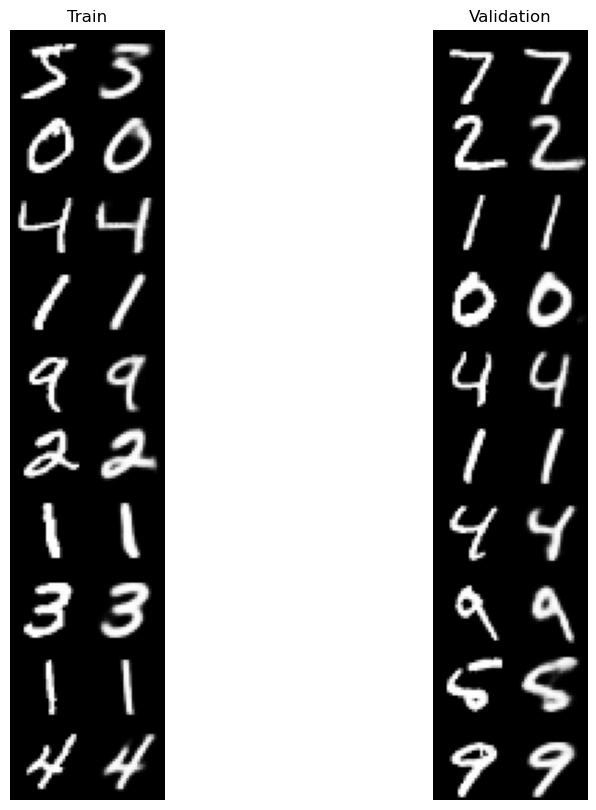

In [15]:
fig = plt.figure(figsize=(10, 10))
for fid_idx, (data, title) in enumerate(
            zip([x_train, x_test], ['Train', 'Validation'])):
    n = 10  # figure with 10 x 2 digits
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * 2))
    decoded = vae.predict(data[:batch_size], verbose=0)
    for i in range(10):
        figure[i * digit_size: (i + 1) * digit_size,
               :digit_size] = data[i, :].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               digit_size:] = decoded[i, :].reshape(digit_size, digit_size)
    ax = fig.add_subplot(1, 2, fid_idx + 1)
    ax.imshow(figure, cmap='Greys_r')
    ax.set_title(title)
    ax.axis('off')
plt.show()

### Создание новых данных
**Задание 4** Написать код для создания новых образцов изображений из обученного VAE. Для этого нужно выбрать из априорного распределения $p(t)$, а затем из вероятности $p(x \mid t)$.

**Обратите внимание**, что выборка, которую вы записали в Задаче 2, относится к вариационному распределению $q(t \mid x)$, а здесь вам нужно взять исходную выборку.

In [16]:
n_samples = 10  # To pass automatic grading please use at least 2 samples here.
# YOUR CODE HERE.
# ...
# sampled_im_mean is a tf.Tensor of size 10 x 784 with 10 random
# images sampled from the vae model.
_mean = tf.zeros([n_samples, original_dim], dtype=tf.float32)
_std =tf.ones([n_samples, original_dim], dtype=tf.float32)
t_samples = tf.random.normal([n_samples, latent_dim], mean=0, stddev=1, dtype=tf.float32)
sampled_im_mean = decoder(t_samples)

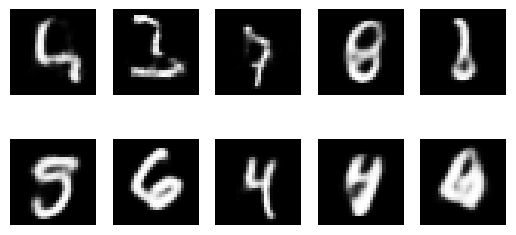

In [17]:
sampled_im_mean_np = sampled_im_mean.numpy()
# Show the sampled images.
plt.figure()
for i in range(n_samples):
    ax = plt.subplot(n_samples // 5 + 1, 5, i + 1)
    plt.imshow(sampled_im_mean_np[i, :].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

## Условный VAE MNIST

В последнем задании мы изменним свой код, чтобы получить условный вариационный автоэнкодер [1]. Идея очень проста: чтобы иметь возможность контролировать сгенерированные вами выборки, мы обусловливаем все распределения некоторой дополнительной информацией. В нашем случае этой дополнительной информацией будет метка класса (цифра на изображении, от 0 до 9).

![](https://github.com/hse-aml/bayesian-methods-for-ml/blob/master/week5/CVAE.png?raw=1)

Итак, теперь и вероятность, и вариационное распределение зависят от метки класса: $p(x \mid t, \text{label}, w)$, $q(t \mid x, \text{label}, \phi )$.

Единственное, что вам нужно изменить в своем коде, это объединить входное изображение $x$ с (one-hot) меткой этого изображения для передачи в кодировщик $q$ и объединить скрытую переменную $t$ с той же меткой для передачи в декодер $p$. Обратите внимание, что это немного сложнее сделать со сверточной моделью кодера/декодера.

[1] Sohn, Kihyuk, Honglak Lee, and Xinchen Yan. “Learning Structured Output Representation using Deep Conditional Generative Models.” Advances in Neural Information Processing Systems. 2015.

### Последняя задача


**Задача 5.1** Здесь будет повторно внедрен CVAE модель, т.е. будут использованы  ```create_encoder``` и ```create_decoder```, определенные ранее (теперь вы можете понять, почему они принимают размер ввода в качестве аргумента ;) ). также будет использоваться слой Keras `concatenate` для объединения меток с входными данными и скрытым кодом.


In [18]:
# One-hot labels placeholder.

batch_size = 100
original_dim = 784 # Number of pixels in MNIST images.
latent_dim = 10 # d, dimensionality of the latent code t.
intermediate_dim = 256 # Size of the hidden layer.
epochs = 200

x = Input(batch_shape=(batch_size, original_dim))
label = Input(batch_shape=(batch_size, 10))

def create_encoder2(input_dim):
    # Encoder network.
    # We instantiate these layers separately so as to reuse them later
    encoder = Sequential(name='encoder')
    encoder.add(InputLayer([input_dim]))

    def to_cond_feature_maps(z):
        x_flat = z[:, :-10]          # (B, 784)
        y      = z[:, -10:]          # (B, num_classes)

        x_img = tf.reshape(x_flat, (-1, 28, 28, 1))

        y_map = tf.reshape(y, (-1, 1, 1, 10))
        y_map = tf.tile(y_map, [1, 28, 28, 1])

        return tf.concat([x_img, y_map], axis=-1)

    encoder.add(Lambda(to_cond_feature_maps, output_shape=(28, 28, 1 + 10)))

    encoder.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    encoder.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    encoder.add(Flatten())
    encoder.add(Dense(2 * latent_dim))
    return encoder

encoder2 = create_encoder2(original_dim + 10)

get_t_mean = Lambda(lambda h: h[:, :latent_dim])
get_t_log_var = Lambda(lambda h: h[:, latent_dim:])

h = encoder2(keras.layers.concatenate([x,label], 1))
cond_t_mean = get_t_mean(h)
cond_t_log_var = get_t_log_var(h)

# Sampling from the distribution
#     q(t | x) = N(t_mean, exp(t_log_var))
# with reparametrization trick.

t = Lambda(sampling, output_shape=(latent_dim,))([cond_t_mean, cond_t_log_var])

def create_decoder2(input_dim):
    # Decoder network
    # We instantiate these layers separately so as to reuse them later
    decoder = Sequential(name='decoder2')
    decoder.add(InputLayer([input_dim]))
    decoder.add(Dense(7 * 7 * 64, activation='relu'))
    decoder.add(Reshape((7, 7, 64)))
    decoder.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(1, kernel_size=3, padding='same', activation='sigmoid'))
    decoder.add(Flatten())
    return decoder
decoder2 = create_decoder2(latent_dim + 10)
x_decoded_mean = decoder2(keras.layers.concatenate([t,label] ,1))
x_decoded_mean = VLB_Loss()([x, x_decoded_mean, cond_t_mean, cond_t_log_var])


In [19]:
# train the VAE on MNIST digits
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# One hot encoding.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

#### Определение функции ошибки и модели

In [20]:
cvae = Model([x, label], x_decoded_mean)
cvae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07,\
                amsgrad=False, name='Adam'))

#### Обучение модели

In [21]:
hist = cvae.fit(x=[x_train, y_train],
                y=x_train,
                shuffle=True,
                epochs=epochs,
                batch_size=batch_size,
                validation_data=([x_test, y_test], x_test),
                callbacks=[early_stopping],
                verbose=1)

Epoch 1/200
batch_size = 100, number_of_pixels = 784 kl_size = (100,)
batch_size = 100, number_of_pixels = 784 kl_size = (100,)
599/600 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 211.0397batch_size = 100, number_of_pixels = 784 kl_size = (100,)
600/600 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - loss: 154.3818 - val_loss: 110.1535
Epoch 2/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - loss: 107.5906 - val_loss: 104.0418
Epoch 3/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - loss: 103.4505 - val_loss: 101.2644
Epoch 4/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - loss: 101.3044 - val_loss: 100.1259
Epoch 5/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - loss: 99.9326 - val_loss: 98.8025
Epoch 6/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - loss: 98.8643 - val_loss: 98.1233
Epoch 7/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - loss: 98.0590 - val_loss: 97.3117
Epoch 8/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - loss: 97.4006 - val_loss: 96.7179
Epoch 9/200
600/600 ━━━━━━━━━━━━

#### Визуализация реконструкции для обучения и проверки данных

batch_size = 32, number_of_pixels = 784 kl_size = (32,)
batch_size = None, number_of_pixels = 784 kl_size = (None,)


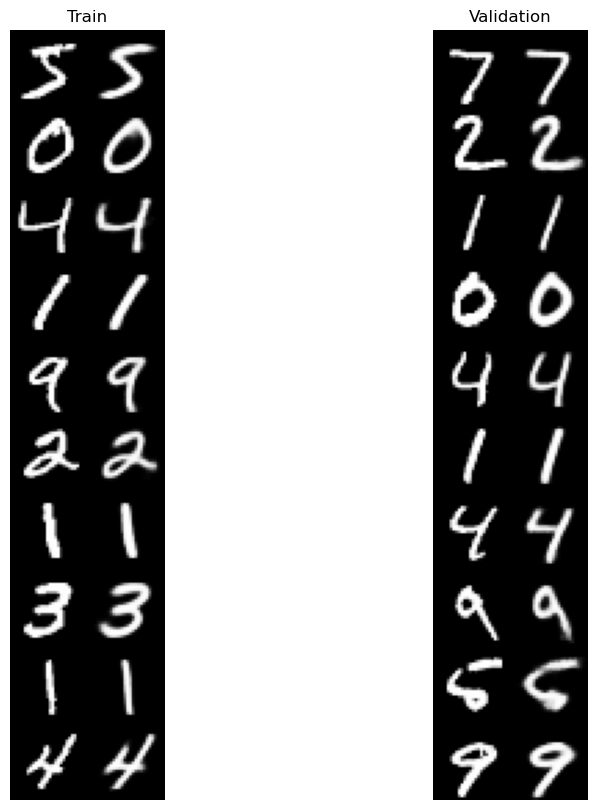

In [22]:
fig = plt.figure(figsize=(10, 10))
for fid_idx, (x_data, y_data, title) in enumerate(
            zip([x_train, x_test], [y_train, y_test], ['Train', 'Validation'])):
    n = 10  # figure with 10 x 2 digits
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * 2))
    decoded = cvae.predict([x_data[:batch_size], y_data[:batch_size]], verbose=0)
    for i in range(10):
        figure[i * digit_size: (i + 1) * digit_size,
               :digit_size] = x_data[i, :].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               digit_size:] = decoded[i, :].reshape(digit_size, digit_size)
    ax = fig.add_subplot(1, 2, fid_idx + 1)
    ax.imshow(figure, cmap='Greys_r')
    ax.set_title(title)
    ax.axis('off')
plt.show()

### Условные новые данные

**Задание 5.2** Реализовать условное моделирование из распределения $p(x \mid t, \text{label})$, сначала выбирая из априорного $p(t)$, а затем выбирая из вероятности $p(x \mid т, \text{метка})$.

In [23]:
# Prepare one hot labels of form
#   0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 ...
# to sample five zeros, five ones, etc
n_samples = 50
curr_labels = np.eye(10)
curr_labels = np.repeat(curr_labels, 5, axis=0)  # Its shape is 50 x 10.
# YOUR CODE HERE.
# ...
# cond_sampled_im_mean is a tf.Tensor of size 50 x 784 with 5 random zeros,
# then 5 random ones, etc sampled from the cvae model.
#curr_labels.tolist()

In [24]:
_mean = tf.zeros([n_samples, original_dim], dtype=tf.float32)
_std =tf.ones([n_samples, original_dim], dtype=tf.float32)
t_samples = tf.random.normal([n_samples, latent_dim], mean=0, stddev=1, dtype=tf.float32)
curr_labels_tensor = tf.convert_to_tensor(curr_labels.tolist())
cond_sampled_im_mean = decoder2(tf.concat([t_samples, curr_labels_tensor],1))

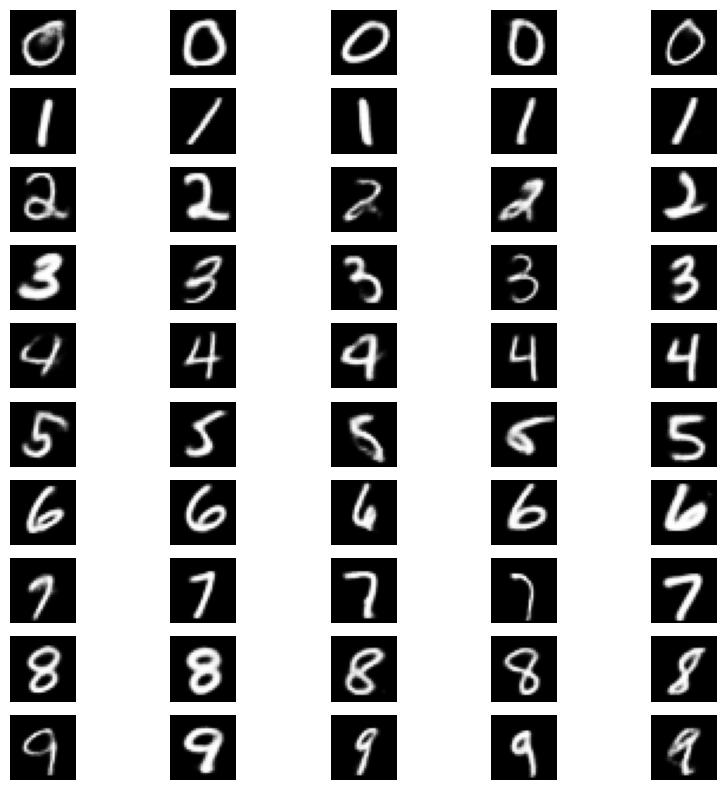

In [25]:
cond_sampled_im_mean_np = cond_sampled_im_mean.numpy()
# Show the sampled images.
plt.figure(figsize=(10, 10))
global_idx = 0
for digit in range(10):
    for _ in range(5):
        ax = plt.subplot(10, 5, global_idx + 1)
        plt.imshow(cond_sampled_im_mean_np[global_idx, :].reshape(28, 28), cmap='gray')
        ax.axis('off')
        global_idx += 1
plt.show()

# CIFAR10

## Вариационный автокодировщик

### Отрицательная вариационная нижняя граница

**Задача 1**
Получим вариационную нижнюю границу для непрерывной смеси нормальных распределений $p(x_i\mid t_i, w) = \mathcal{N}\!\left(\mu_x​(t;w),
\sigma_x^2I\right)$.
$$
{\cal L(w,q)} = VLB =   \sum_{i=1}^N \text{VLB}_i =  \sum_i\mathbf{M}_{q_i}\log\frac{p(x_i\mid t_i, w) p(t_i)}{q_{i}(t_i)} = \sum_i \mathbf{M}_{q_i} \log p(x_i\mid t_i, w)  +  \underbrace{\mathbf{M}_{q_i}\log \frac{p(t_i)}{q_i(t_i)}}_{-D_{kl}(q_i(t_i)|| p(t_i))}
$$
$$
\begin{align*}
D_{kl}(q_i(t_i)|| p(t_i)) &=
\\
&=\sum_{j=1}^M\left(-\log\sigma(t_i) + \frac{\sigma^2(t_i) +\mu^2(t_i)-1}{2}\right) = M\left(-\log\sigma(t_i) + \frac{\sigma^2(t_i) +\mu^2(t_i)-1}{2}
\right)
\end{align*}
$$
Первый член в выражении для ${\cal L(w,q)}$:
\begin{align}
\sum_i M_{q_i} \log p(x_i \mid t_i, w)
&= \sum_i M_{q_i}\Bigl[
    -\frac{D}{2}\log(2\pi\sigma_x^2)
    - \frac{1}{2\sigma_x^2}\,\lVert x - \mu_x(t,w) \rVert^2
\Bigr] \\
&= \sum_i \Bigl(
    \underbrace{-\frac{D}{2}\log(2\pi\sigma_x^2)}_{\text{не влияем на обучение}}
    - \frac{1}{2\sigma_x^2} M_{q_i}\,\lVert x - \mu_x(t,w) \rVert^2
\Bigr).
\end{align}

$$
\sigma_x^2 = 1 \quad \text{(для простоты)}
$$


$$
\mathrm{VLB}_i
= -\frac{1}{2} M_{q_i}\,\lVert x_i - p(t_i) \rVert^2
  - D_{\mathrm{KL}}\bigl(q_i(t_i)\,\|\,p(t_i)\bigr)
$$


In [26]:
def vlb_binomial(x, x_decoded_mean, t_mean, t_log_var):
    """Returns the value of negative Variational Lower Bound

    The inputs are tf.Tensor
        x: (batch_size x number_of_pixels) matrix with one image per row with zeros and ones
        x_decoded_mean: (batch_size x number_of_pixels) mean of the distribution p(x | t), real numbers from 0 to 1
        t_mean: (batch_size x latent_dim) mean vector of the (normal) distribution q(t | x)
        t_log_var: (batch_size x latent_dim) logarithm of the variance vector of the (normal) distribution q(t | x)

    Returns:
        A tf.Tensor with one element (averaged across the batch), VLB
    """
    t_var =  tf.exp(t_log_var)
    kl = -t_log_var/2.0 + (t_var + t_mean**2 - 1)/2.0
    kl = tf.reduce_sum(kl, axis=1)

    sq_error = tf.reduce_sum(tf.square(x - x_decoded_mean), axis=1)

    result = tf.reduce_mean(-0.5*sq_error - kl)
    return -result

In [27]:
class VLB_Loss(Layer):
    """
    Слой для добавления ошибки (нижней вариационной границы) в ошибки для нейросети
    """
    def call(self, input):
        x, x_decoded_mean, t_mean, t_log_var = input
        loss = vlb_binomial(x, x_decoded_mean, t_mean, t_log_var)
        self.add_loss(loss) #ошибка по которой будет обучаться модель
        return x_decoded_mean

    def compute_output_shape(self, input_shape):
        return input_shape[1]

### Определение Encoder / decoder

**Задание 2**  Ниже приведен код, который  определяет энкодер и декодер, и реализует выборку с приемом репараметризации в предоставленном пространстве.

In [28]:
batch_size = 100
original_dim = 3072 # Number of pixels in MNIST images.
latent_dim = 30 # d, dimensionality of the latent code t.
intermediate_dim = 256 # Size of the hidden layer.
epochs = 200

x = Input(batch_shape=(batch_size, original_dim))
def create_encoder(input_dim):
    # Encoder network.
    # We instantiate these layers separately so as to reuse them later
    encoder = Sequential(name='encoder')
    encoder.add(InputLayer([input_dim]))
    encoder.add(Reshape((32, 32, 3)))
    encoder.add(Conv2D(32, kernel_size=3, strides=2,  padding='same', activation='relu'))
    encoder.add(Conv2D(64, kernel_size=3, strides=2,  padding='same', activation='relu'))
    encoder.add(Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'))
    encoder.add(Flatten())
    encoder.add(Dense(intermediate_dim, activation='relu'))
    encoder.add(Dense(2 * latent_dim))
    return encoder
encoder = create_encoder(original_dim)

get_t_mean = Lambda(lambda h: h[:, :latent_dim])
get_t_log_var = Lambda(lambda h: h[:, latent_dim:])
h = encoder(x)
t_mean = get_t_mean(h)
t_log_var = get_t_log_var(h)

# Sampling from the distribution
#     q(t | x) = N(t_mean, exp(t_log_var))
# with reparametrization trick.
def sampling(args):
    """Returns sample from a distribution N(args[0], diag(args[1]))

    The sample should be computed with reparametrization trick.

    The inputs are tf.Tensor
        args[0]: (batch_size x latent_dim) mean of the desired distribution
        args[1]: (batch_size x latent_dim) logarithm of the variance vector of the desired distribution

    Returns:
        A tf.Tensor of size (batch_size x latent_dim), the samples.
    """
    t_mean, t_log_var = args
    t_std = tf.exp(0.5*t_log_var)
    eps = tf.random.normal(tf.shape(t_mean), mean=0, stddev=1, dtype=tf.float32)*t_std + t_mean
    return eps

t = Lambda(sampling, output_shape=(latent_dim,))([t_mean, t_log_var])

def create_decoder(input_dim):
    # Decoder network
    # We instantiate these layers separately so as to reuse them later
    decoder = Sequential(name='decoder')
    decoder.add(InputLayer([input_dim]))
    decoder.add(Dense(4 * 4 * 128, activation='relu'))
    decoder.add(Reshape((4, 4, 128)))
    decoder.add(Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(3, kernel_size=3, padding='same', activation='sigmoid'))
    decoder.add(Flatten())
    return decoder
decoder = create_decoder(latent_dim)
x_decoded_mean = decoder(t)
x_decoded_mean = VLB_Loss()([x, x_decoded_mean, t_mean, t_log_var])

### Обучение модели

**Задание 3** Запустите указанные ниже ячейки, чтобы обучить модель с настройками по умолчанию. Измените параметры, чтобы получить лучшие результаты. Особенно обратите внимание на архитектуру кодировщика/декодера (например, использование большего количества слоев, возможно, сделав их сверточными), скорость обучения и количество эпох.

In [29]:
vae = Model(x, x_decoded_mean)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07,\
                amsgrad=False, name='Adam'))

#### Загрузка и подготовка данных

In [30]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# One hot encoding.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

#### Обучение модели

In [31]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

hist = vae.fit(x=x_train, y=x_train,
               shuffle=True,
               epochs=epochs,
               batch_size=batch_size,
               validation_data=(x_test, x_test),
               callbacks=[early_stopping],
               verbose=1)

Epoch 1/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 81ms/step - loss: 63.0591 - val_loss: 52.1413
Epoch 2/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 50.9124 - val_loss: 49.0895
Epoch 3/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - loss: 48.4849 - val_loss: 47.9519
Epoch 4/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - loss: 47.6649 - val_loss: 47.3714
Epoch 5/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - loss: 47.3072 - val_loss: 47.3733
Epoch 6/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - loss: 47.0092 - val_loss: 46.9106
Epoch 7/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - loss: 46.8234 - val_loss: 46.7567
Epoch 8/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - loss: 46.6542 - val_loss: 46.6565
Epoch 9/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - loss: 46.5224 - val_loss: 46.6676
Epoch 10/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 46.3986 - val_loss: 46.4165
Epoch 11/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - loss: 46.3083 - val_loss: 46.46

#### Визуализация реконструкции для обучения и проверки данных
На рисунке ниже вы можете увидеть способность вашей сети к реконструкции на основе данных обучения и валидации. В каждом из двух изображений левый столбец — это изображения MNIST, а правый столбец — это соответствующее изображение после прохождения через автоэнкодер (или, точнее, среднее значение биномиального распределения по выходным изображениям).

Обратите внимание, что получение наилучшей возможной реконструкции не является целью VAE, дивергенция Кульбака-Лейблера KL функции потерь ухудшает производительность реконструкции. Но реконструкция в любом случае должна быть разумной, и они предоставляют визуальный инструмент отладки кода.

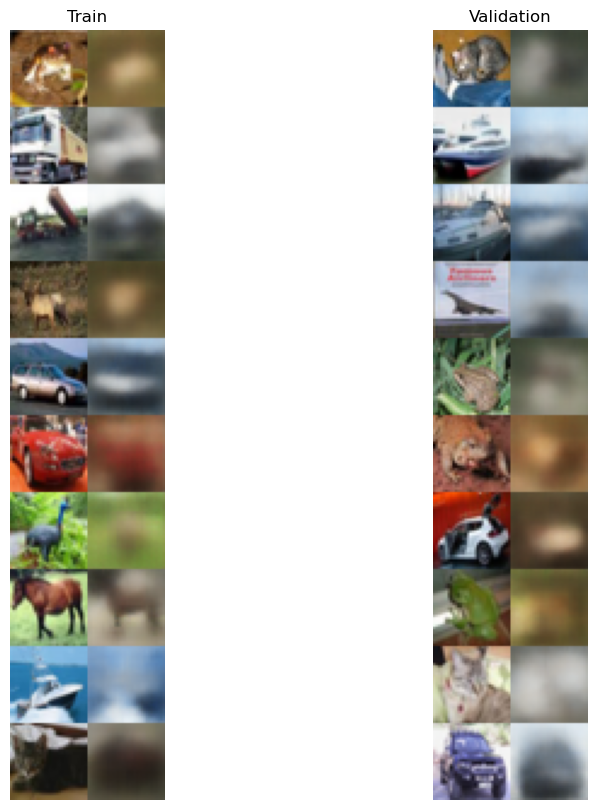

In [32]:
fig = plt.figure(figsize=(10, 10))
for fid_idx, (data, title) in enumerate(
            zip([x_train, x_test], ['Train', 'Validation'])):
    n = 10  # figure with 10 x 2 digits
    digit_size = 32
    figure = np.zeros((digit_size * n, digit_size * 2, 3))
    decoded = vae.predict(data[:batch_size], verbose=0)
    for i in range(10):
        figure[i * digit_size: (i + 1) * digit_size,
               :digit_size, :] = data[i, :].reshape(digit_size, digit_size, 3)
        figure[i * digit_size: (i + 1) * digit_size,
               digit_size:, :] = decoded[i, :].reshape(digit_size, digit_size, 3)
    ax = fig.add_subplot(1, 2, fid_idx + 1)
    ax.imshow(figure)
    ax.set_title(title)
    ax.axis('off')
plt.show()

### Создание новых данных
**Задание 4** Написать код для создания новых образцов изображений из обученного VAE. Для этого нужно выбрать из априорного распределения $p(t)$, а затем из вероятности $p(x \mid t)$.

**Обратите внимание**, что выборка, которую вы записали в Задаче 2, относится к вариационному распределению $q(t \mid x)$, а здесь вам нужно взять исходную выборку.

In [33]:
n_samples = 10

t_samples = tf.random.normal([n_samples, latent_dim], mean=0, stddev=1, dtype=tf.float32)
sampled_im_mean = decoder(t_samples)

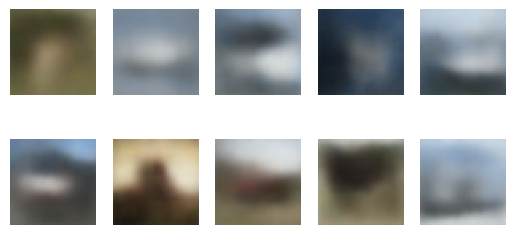

In [34]:
sampled_im_mean_np = sampled_im_mean.numpy()
# Show the sampled images.
plt.figure()
for i in range(n_samples):
    ax = plt.subplot(n_samples // 5 + 1, 5, i + 1)
    plt.imshow(sampled_im_mean_np[i, :].reshape(32, 32, 3))
    ax.axis('off')
plt.show()

## Условный VAE

### Последняя задача


**Задача 5.1** Здесь будет повторно внедрен CVAE модель, т.е. будут использованы  ```create_encoder``` и ```create_decoder```, определенные ранее (теперь вы можете понять, почему они принимают размер ввода в качестве аргумента ;) ). также будет использоваться слой Keras `concatenate` для объединения меток с входными данными и скрытым кодом.


In [35]:
# One-hot labels placeholder.

batch_size = 100
original_dim = 3072 # Number of pixels in MNIST images.
latent_dim = 30 # d, dimensionality of the latent code t.
intermediate_dim = 256 # Size of the hidden layer.
epochs = 200

x = Input(batch_shape=(batch_size, original_dim))
label = Input(batch_shape=(batch_size, 10))

def create_encoder2(input_dim):
    # Encoder network.
    # We instantiate these layers separately so as to reuse them later
    encoder = Sequential(name='encoder')
    encoder.add(InputLayer([input_dim]))

    def to_cond_feature_maps(z):
        x_flat = z[:, :-10]          # (B, 784)
        y      = z[:, -10:]          # (B, num_classes)

        x_img = tf.reshape(x_flat, (-1, 32, 32, 3))

        y_map = tf.reshape(y, (-1, 1, 1, 10))
        y_map = tf.tile(y_map, [1, 32, 32, 1])

        return tf.concat([x_img, y_map], axis=-1)

    encoder.add(Lambda(to_cond_feature_maps, output_shape=(32, 32, 3 + 10)))

    encoder.add(Conv2D(32, kernel_size=3, strides=2,  padding='same', activation='relu'))
    encoder.add(Conv2D(64, kernel_size=3, strides=2,  padding='same', activation='relu'))
    encoder.add(Conv2D(128, kernel_size=3, strides=2, padding='same', activation='relu'))
    encoder.add(Flatten())
    encoder.add(Dense(intermediate_dim, activation='relu'))
    encoder.add(Dense(2 * latent_dim))
    return encoder

encoder2 = create_encoder2(original_dim + 10)

get_t_mean = Lambda(lambda h: h[:, :latent_dim])
get_t_log_var = Lambda(lambda h: h[:, latent_dim:])

h = encoder2(keras.layers.concatenate([x,label], 1))
cond_t_mean = get_t_mean(h)
cond_t_log_var = get_t_log_var(h)

# Sampling from the distribution
#     q(t | x) = N(t_mean, exp(t_log_var))
# with reparametrization trick.

t = Lambda(sampling, output_shape=(latent_dim,))([cond_t_mean, cond_t_log_var])

def create_decoder2(input_dim):
    # Decoder network
    # We instantiate these layers separately so as to reuse them later
    decoder = Sequential(name='decoder')
    decoder.add(InputLayer([input_dim]))
    decoder.add(Dense(4 * 4 * 128, activation='relu'))
    decoder.add(Reshape((4, 4, 128)))
    decoder.add(Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='relu'))
    decoder.add(Conv2DTranspose(3, kernel_size=3, padding='same', activation='sigmoid'))
    decoder.add(Flatten())
    return decoder
decoder2 = create_decoder2(latent_dim + 10)
x_decoded_mean = decoder2(keras.layers.concatenate([t,label] ,1))
x_decoded_mean = VLB_Loss()([x, x_decoded_mean, cond_t_mean, cond_t_log_var])


In [36]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# One hot encoding.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

#### Определение функции ошибки и модели

In [37]:
cvae = Model([x, label], x_decoded_mean)
cvae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07,\
                amsgrad=False, name='Adam'))

#### Обучение модели

In [38]:
hist = cvae.fit(x=[x_train, y_train],
                y=x_train,
                shuffle=True,
                epochs=epochs,
                batch_size=batch_size,
                validation_data=([x_test, y_test], x_test),
                callbacks=[early_stopping],
                verbose=1)

Epoch 1/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 84ms/step - loss: 63.1595 - val_loss: 51.4843
Epoch 2/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - loss: 49.7000 - val_loss: 48.8971
Epoch 3/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - loss: 48.4709 - val_loss: 48.0339
Epoch 4/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - loss: 47.7451 - val_loss: 47.0759
Epoch 5/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - loss: 46.8501 - val_loss: 46.4358
Epoch 6/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - loss: 46.2703 - val_loss: 46.0388
Epoch 7/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - loss: 45.9476 - val_loss: 45.7297
Epoch 8/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - loss: 45.7185 - val_loss: 45.8546
Epoch 9/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - loss: 45.6145 - val_loss: 45.6168
Epoch 10/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 45.4841 - val_loss: 45.5723
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.


#### Визуализация реконструкции для обучения и проверки данных

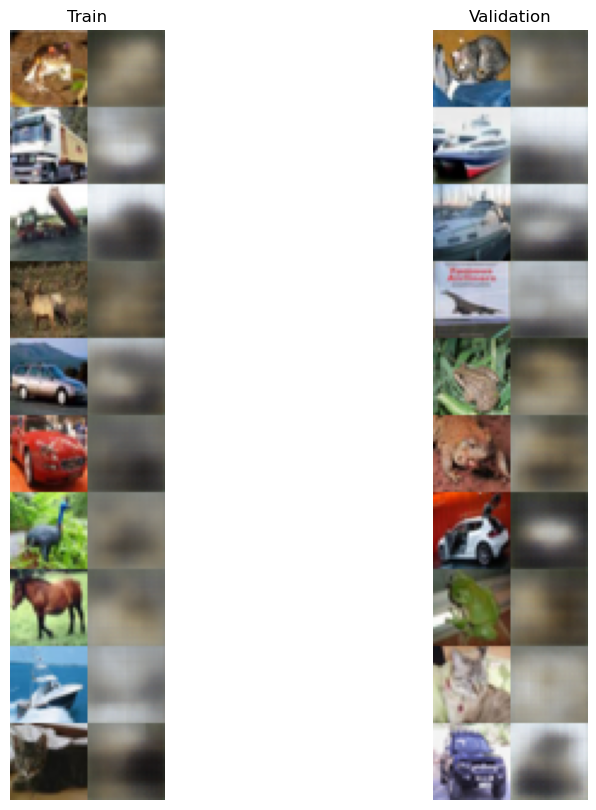

In [39]:
fig = plt.figure(figsize=(10, 10))
for fid_idx, (x_data, y_data, title) in enumerate(
            zip([x_train, x_test], [y_train, y_test], ['Train', 'Validation'])):
    n = 10
    digit_size = 32
    figure = np.zeros((digit_size * n, digit_size * 2, 3))
    decoded = cvae.predict([x_data[:batch_size], y_data[:batch_size]], verbose=0)
    for i in range(10):
        figure[i * digit_size: (i + 1) * digit_size,
               :digit_size, :] = x_data[i, :].reshape(digit_size, digit_size, 3)
        figure[i * digit_size: (i + 1) * digit_size,
               digit_size:, :] = decoded[i, :].reshape(digit_size, digit_size, 3)
    ax = fig.add_subplot(1, 2, fid_idx + 1)
    ax.imshow(figure, cmap='Greys_r')
    ax.set_title(title)
    ax.axis('off')
plt.show()

### Условные новые данные

**Задание 5.2** Реализовать условное моделирование из распределения $p(x \mid t, \text{label})$, сначала выбирая из априорного $p(t)$, а затем выбирая из вероятности $p(x \mid т, \text{метка})$.

In [40]:
n_samples = 50
curr_labels = np.eye(10)
curr_labels = np.repeat(curr_labels, 5, axis=0)  # Its shape is 50 x 10.

In [41]:
_mean = tf.zeros([n_samples, original_dim], dtype=tf.float32)
_std =tf.ones([n_samples, original_dim], dtype=tf.float32)
t_samples = tf.random.normal([n_samples, latent_dim], mean=0, stddev=1, dtype=tf.float32)
curr_labels_tensor = tf.convert_to_tensor(curr_labels.tolist())
cond_sampled_im_mean = decoder2(tf.concat([t_samples, curr_labels_tensor],1))

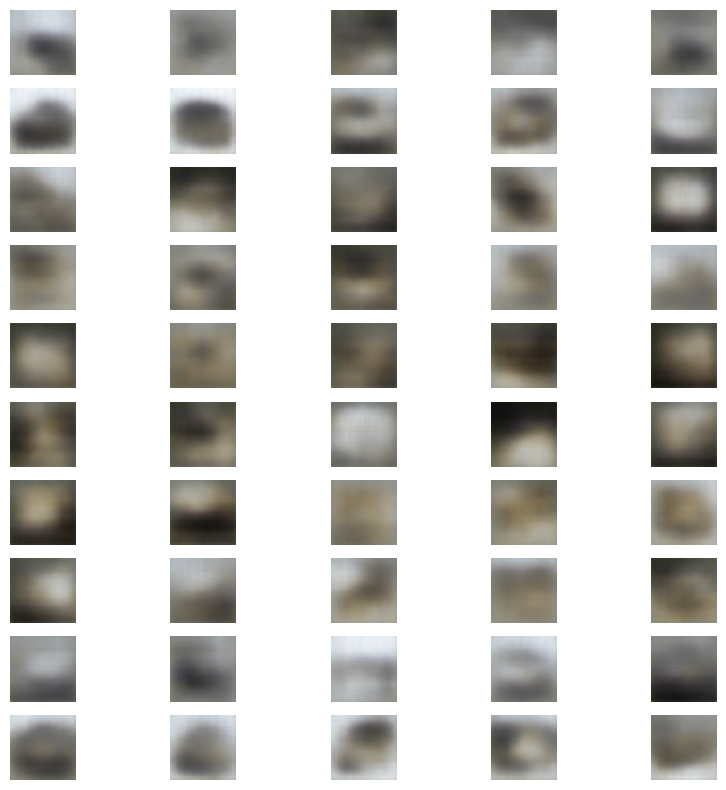

In [42]:
cond_sampled_im_mean_np = cond_sampled_im_mean.numpy()
# Show the sampled images.
plt.figure(figsize=(10, 10))
global_idx = 0
for digit in range(10):
    for _ in range(5):
        ax = plt.subplot(10, 5, global_idx + 1)
        plt.imshow(cond_sampled_im_mean_np[global_idx, :].reshape(32, 32, 3))
        ax.axis('off')
        global_idx += 1
plt.show()

0 -> Airplane

1 -> Automobile

2 -> Bird

3 -> Cat

4 -> Deer

5 -> Dog

6 -> Frog

7 -> Horse

8 -> Ship

9 -> Truck

Выводы:
Были построены модели вариционного автоэнкодера и условного автоэнкодера для базы данных CIFAR10.
Реконструированные данные сильно размыты. Сгенерированные изображения по нормальному шуму и по меткам также сильно размыты и плохо различимы.

Для улучшения качества модели было сделано:
1. Добавлена ранняя остановка с возращениям к наилучшим значениям (при неулучшении валидационной ошибки на протяжении 10 эпох) - останавливает модель при переобучении
2. Добавлена сверточная основа для энкодера и декодера. По сравнению с линейными энкодерами и декодарами модель стала лучше выделять ключевые признаки изображений, однако изображения всё ещё неразборчивы
3. Варьировано количество латентных переменных. Слишком маленькие значения <10 сильно размывают изображения (мало для обобщения данных). Слишком большие значения >500 сильно размывают изображения (скорее всего слишком слабая архитектура энкодера и декодера)
4. Были попытки добавить параметр регуляризации (коэффициент при дивергенции Кульбака-Лейблера). При beta=0.1 восстановленные данные становятся более четкими, однако новые сгенерированные изображения имеют дефекты (например, черные поля по центру)